In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt

import env.trading_env as te
import features.feature_engineering as fe
importlib.reload(te)
importlib.reload(fe)

from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback

In [2]:
# Read data
df = pd.read_excel('../data/data.xlsx', skiprows=6, header=0)
df.columns = ['date', 'gold', 'silver', 'copper']
df = df[pd.to_datetime(df['date'], errors='coerce').notna()]
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [3]:
# Feature engineering
features_final = fe.build_features(df)

# Split
train = features_final[features_final.index <= '2023-12-31']
test = features_final[features_final.index >= '2024-01-01']
price_train = df[df.index.isin(train.index)]
price_test = df[df.index.isin(test.index)]

print(f"Train: {len(train)}days, Test: {len(test)}days")

Train: 2592days, Test: 485days


finish training


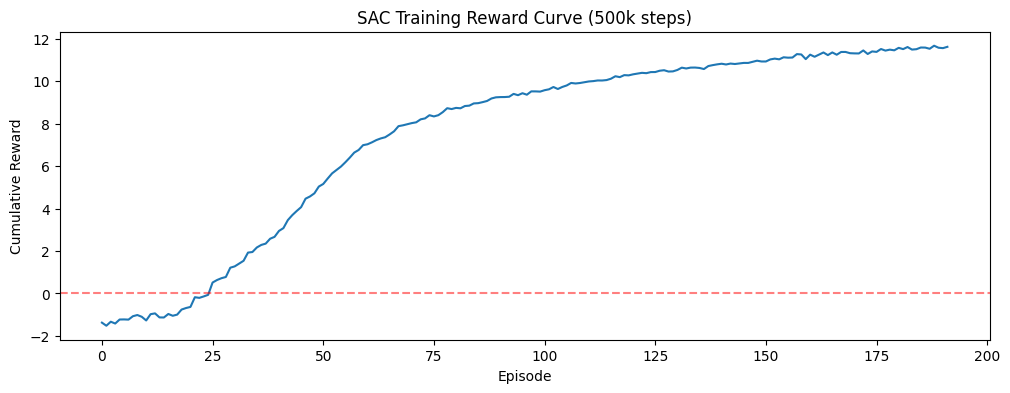

Average reward for the last 10 episodes: 11.5767


In [4]:
class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.current_rewards = []
    
    def _on_step(self):
        reward = self.locals['rewards'][0]
        self.current_rewards.append(reward)
        
        if self.locals['dones'][0]:
            self.episode_rewards.append(sum(self.current_rewards))
            self.current_rewards = []
        return True

# Initialising the environment
train_env = te.MetalTradingEnv(train, price_train)
callback_sac = RewardCallback()

model_sac500k = SAC(
    "MlpPolicy",
    train_env,
    learning_rate=3e-4,
    batch_size=256,
    buffer_size=100_000,
    learning_starts=1000,
    gamma=0.99,
    verbose=0
)

model_sac500k.learn(total_timesteps=500_000, callback=callback_sac)
print("finish training")



# plot
plt.figure(figsize=(12, 4))
plt.plot(callback_sac.episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("SAC Training Reward Curve (500k steps)")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.show()

print(f"Average reward for the last 10 episodes: {sum(callback_sac.episode_rewards[-10:])/10:.4f}")